# **Convex Optimization Project 6**
Name: Reza Kahidi\
Student Number: 810101249

In [1]:
import cvxpy as cp
import numpy as np
from matplotlib import pyplot as plt

## Data

In [25]:
"""
This file contains the following variables that you need:
    - y and s: the problem data.
    - T, N, M: the problem dimensions.
    - a_true: the true value for you to compare against.

We also provide the following helper functions for plotting and other utility:

    - visualize_data(): Generates a plot of y, and s * a_true.
        Call plt.show() after calling the function to make the plot visible.

    - visualize_estimate(a): Generates a plot of y, estimated hat a, and s * hat a.
        Call plt.show() after calling the function to make the plot visible.
        Here, a needs to be an array of values, not cvxpy variable!

    - visualize_polished(a_polished): Generates a plot of y, a_polished, and s * a_polished.
        Call plt.show() after calling the function to make the plot visible.
        Here, a_polished needs to be an array of values, not cvxpy variable!

    - find_nonzero_entries(a): Given the vector a, this function returns the
        indices where a > 0.01.
        Here, a needs to be an array of values, not cvxpy variable!

"""

import numpy as np
import matplotlib.pyplot as plt

################################################################################
# This section of the code sets up a discrete version of the Hodgkin Huxley (H&H)
# model, about which you need to know absolutely nothing.
# The H&H model is used to obtain a realistic template of neural activity.
# You do not need to know or understand any of the code until the next line
# of all #s

# Define model parameters
Cm = 1.0   # Membrane capacitance
I_app = 10.0  # Applied current
E_Na = 55.0   # Sodium reversal potential
E_K = -90.0   # Potassium reversal potential
E_L = -65.0   # Leak reversal potential
g_Na = 120.0   # Maximum sodium conductance
g_K = 36.0   # Maximum potassium conductance
g_L = 0.3   # Maximum leak conductance

# Define time vector
dt = 0.01   # Time step
t_max = 20.0   # Maximum time
t = np.arange(0, t_max + dt, dt)

# Define initial conditions
V = -65.0   # Membrane potential
m = 0.0   # Sodium activation gate
h = 1.0   # Sodium inactivation gate
n = 0.0   # Potassium activation gate

# Define functions for the ion currents and gating variables
def alpha_m(V):
    return 0.1 * (V + 40.0) / (1.0 - np.exp(-(V + 40.0) / 10.0))

def beta_m(V):
    return 4.0 * np.exp(-(V + 65.0) / 18.0)

def alpha_h(V):
    return 0.07 * np.exp(-(V + 65.0) / 20.0)

def beta_h(V):
    return 1.0 / (1.0 + np.exp(-(V + 35.0) / 10.0))

def alpha_n(V):
    return 0.01 * (V + 55.0) / (1.0 - np.exp(-(V + 55.0) / 10.0))

def beta_n(V):
    return 0.125 * np.exp(-(V + 65.0) / 80.0)

def I_Na(V, m, h):
    return g_Na * m**3 * h * (V - E_Na)

def I_K(V, n):
    return g_K * n**4 * (V - E_K)

def I_L(V):
    return g_L * (V - E_L)

# Simulate the H&H model
V_trace = [V]
for i in range(len(t)-1):
    m += dt * (alpha_m(V) * (1.0 - m) - beta_m(V) * m)
    h += dt * (alpha_h(V) * (1.0 - h) - beta_h(V) * h)
    n += dt * (alpha_n(V) * (1.0 - n) - beta_n(V) * n)
    I_ion = I_Na(V, m, h) + I_K(V, n) + I_L(V)
    V += dt * (I_app - I_ion) / Cm
    V_trace.append(V)


# We subsample the template in time for shorter final result
t_sub = t[::10]
V_sub = V_trace[::10]

s = V_sub[:200] - V_sub[199]
M = s.shape[0]
N = 2000

# This generates the ground truth activations a_true
a_true = np.zeros(N)
acts = np.array([200,250,345,460,500, 800, 850, 1100, 1500, 1700], dtype=int)
np.random.seed(50)
for i in range(acts.shape[0]):
    a_true[acts[i]] = np.maximum(np.random.normal(1,0.3),1)
# We generate the ground truth signal
y = np.convolve(s, a_true) + np.random.normal(0,80,M+N-1)

# We divide by 8 to achieve realistic bounds on the ephys recording
y = y / 8
s = s / 8

# The time axis is in data points, not ms!
times = np.arange(0,2199,1)
T = M + N - 1
################################################################################

# Use the plotting functions provided below whenever helpful.

def visualize_data():
    plt.subplots(2,1)
    plt.subplots_adjust(left=0.1,
                        bottom=0.1,
                        right=0.9,
                        top=0.9,
                        wspace=0.4,
                        hspace=1)

    plt.subplot(211)
    plt.plot(times,y)
    plt.ylabel('y (mV)')
    plt.xlabel('t')

    plt.subplot(212)
    plt.plot(times,np.convolve(s,a_true),label = 'True')
    plt.ylabel('$s * a_{true}$')
    plt.xlabel('t')

def visualize_estimate(a):
    plt.subplots(3,1)
    plt.subplots_adjust(left=0.1,
                        bottom=0.1,
                        right=0.9,
                        top=0.9,
                        wspace=0.4,
                        hspace=0.4)

    plt.subplot(311)
    plt.plot(times,y)
    plt.ylabel('y (mV)')

    plt.subplot(312)
    plt.plot(times,np.convolve(s,a_true),label = 'True',linewidth = 3, alpha=0.7)
    plt.plot(times,np.convolve(s,a),label = 'Estimated')
    plt.ylabel(r's * $\hat{a}$')

    plt.subplot(313)
    plt.plot(times[:2000],a_true,label = '$True$',linewidth = 3, alpha=0.7)
    plt.plot(times[:2000],a,label = '$Estimated$')
    plt.ylabel(r'$\hat{a}$')
    plt.legend()
    plt.xlabel('t')

def visualize_polished(a):
    plt.subplots(3,1)
    plt.subplots_adjust(left=0.1,
                        bottom=0.1,
                        right=0.9,
                        top=0.9,
                        wspace=0.4,
                        hspace=0.4)

    plt.subplot(311)
    plt.plot(times,y)
    plt.ylabel('y (mV)')

    plt.subplot(312)
    plt.plot(times,np.convolve(s,a_true),label = 'True',linewidth = 3, alpha=0.7)
    plt.plot(times,np.convolve(s,a),label = 'Estimated')
    plt.ylabel(r's * $\hat{a}_{polished}$')

    plt.subplot(313)
    plt.plot(times[:2000],a_true,label = '$True$',linewidth = 3, alpha=0.7)
    plt.plot(times[:2000],a,label = '$Estimated$')
    plt.ylabel(r'$\hat{a}_{polished}$')
    plt.legend()
    plt.xlabel('t')

def find_nonzero_entries(a):
    ind = np.where(a > 0.01)[0]
    return ind

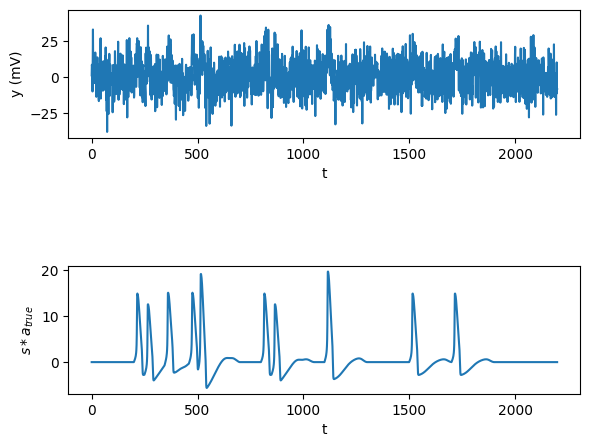

In [26]:
visualize_data()

## Problem

### Part b

Problem status: optimal
Optimal Value = 115.61490868783758
Nonzero indices in estimated activation: [ 198  242  249  345  459  499  799  849 1098 1499 1698]
Nonzero indices in true activation: [ 200  250  345  460  500  800  850 1100 1500 1700]
Matching nonzero indices: [345]


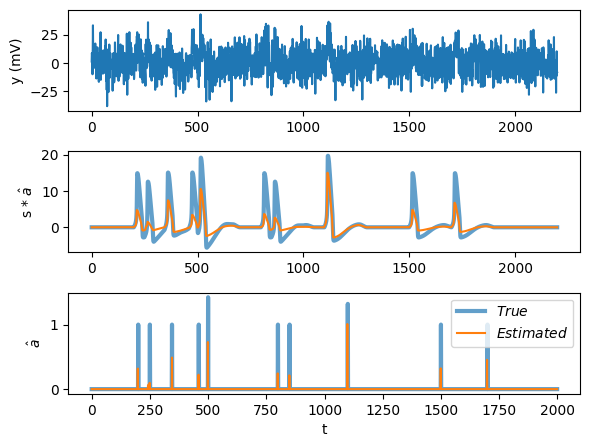

In [27]:
a = cp.Variable(N)

obj = cp.Minimize((1/T) * cp.sum_squares(y - cp.conv(s, a).flatten()) + 2 * cp.sum(a))
const = [a >= 0]
prob = cp.Problem(obj, const)

prob.solve()
print("Problem status:", prob.status)
print("Optimal Value =", prob.value)

a_est = a.value
visualize_estimate(a_est)

nonzero_indices_est = find_nonzero_entries(a_est)
nonzero_indices_true = find_nonzero_entries(a_true)

print("Nonzero indices in estimated activation:", nonzero_indices_est)
print("Nonzero indices in true activation:", nonzero_indices_true)

matching_indices = np.intersect1d(nonzero_indices_est, nonzero_indices_true)
print("Matching nonzero indices:", matching_indices)


The non-zero entries indices of a_est and a_true do not match very well, and the estimated neural signal is not very accurate.

### Part c

Problem status: optimal
Optimal Value = 99.2258467433658
Nonzero indices in polished activation: [ 198  242  249  345  459  499  799  849 1098 1499 1698]
Nonzero indices in true activation: [ 200  250  345  460  500  800  850 1100 1500 1700]
Matching nonzero indices after polishing: [345]


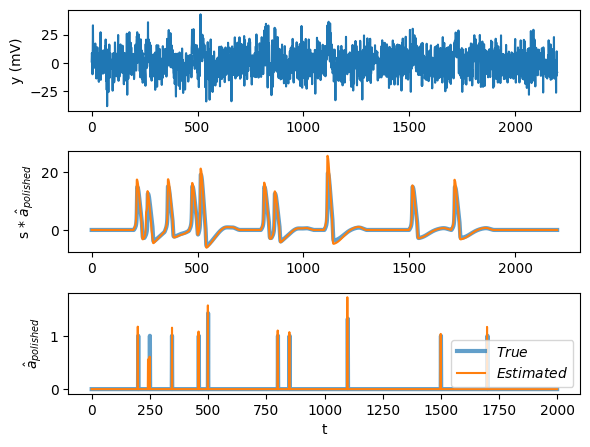

In [28]:
a_pol = cp.Variable(N)

obj_pol = cp.Minimize((1/T) * cp.sum_squares(y - cp.conv(s, a_pol).flatten()))
const_pol = [a_pol >= 0]
for i in range(N):
    if i not in nonzero_indices_est:
        const_pol.append(a_pol[i] == 0)

prob_pol = cp.Problem(obj_pol, const_pol)
prob_pol.solve()
print("Problem status:", prob_pol.status)
print("Optimal Value =", prob_pol.value)

a_pol_est = a_pol.value
visualize_polished(a_pol_est)

nonzero_indices_pol = find_nonzero_entries(a_pol_est)
nonzero_indices_true = find_nonzero_entries(a_true)

print("Nonzero indices in polished activation:", nonzero_indices_pol)
print("Nonzero indices in true activation:", nonzero_indices_true)

matching_indices_pol = np.intersect1d(nonzero_indices_pol, nonzero_indices_true)
print("Matching nonzero indices after polishing:", matching_indices_pol)

Here we have a better estimation signal and polishing improve the estimate of the neural signal.